<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/07_MaquinasVectoresSoporte_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Máquinas de Vectores de Soporte (SVM)

**Las máquinas de vectores de soporte (SVM)** son una categoría muy utilizada y poderosa de algoritmos de aprendizaje automático. Hay muchas variaciones en la idea básica de un SVM. Un SVM intenta **separar al máximo** las clases al encontrar el **vector de soporte** con la tasa de error más baja o la separación máxima. Los SVM pueden usar muchos tipos de **funciones del núcleo**. Las funciones del núcleo más comunes son **lineal** y la **función de base radial** o **RBF**. La función de base lineal intenta separar las clases al encontrar hiperplanos en el espacio de características que separan las clases al máximo. El RBF utiliza un conjunto de núcleos locales en forma de Gauss para encontrar una separación no lineal de las clases.


Consiste en seleccionar como clasificador óptimo al que se conoce como maximal margin hyperplane o hiperplano óptimo de separación, que se corresponde con el hiperplano que se encuentra más alejado de todas las observaciones de entrenamiento.
Para obtenerlo, se tiene que calcular la distancia perpendicular de cada observación a un determinado hiperplano. La menor de estas distancias (conocida como margen) determina como de alejado está el hiperplano de las observaciones de entrenamiento.

*https://rpubs.com/Joaquin_AR/267926

## 1. Librerias y configuraciones previas


In [55]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np


# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math


# Preprocesado y modelado
# ==============================================================================

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Escalar Variables
from sklearn.preprocessing import MinMaxScaler

#configuracion de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

#Creación de modelo
from sklearn import svm

#Evaluación del modelo

from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns


# Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [56]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/mrbedoya/ml-2026/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = '02_GermanCredit_Prep.csv'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [57]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [58]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [59]:
# Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/02_GermanCredit_Prep.csv
dataset descargado exitosamente a: datasets/02_GermanCredit_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones

In [60]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
#sys.path.append(UTILS_PATH)

## Importar Funciones externas
#from funciones import multiple_plot, plot_roc_curve

## 3. Carga del dataset

In [61]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d=pd.read_csv(local_dataset_path)

In [62]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1138 entries, 0 to 1137
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_account_status   1138 non-null   object
 1   loan_duration_mo          1138 non-null   int64 
 2   credit_history            1138 non-null   object
 3   purpose                   1138 non-null   object
 4   loan_amount               1138 non-null   int64 
 5   savings_account_balance   1138 non-null   object
 6   time_employed_yrs         1138 non-null   object
 7   payment_pcnt_income       1138 non-null   int64 
 8   gender_status             1138 non-null   object
 9   other_signators           1138 non-null   object
 10  time_in_residence         1138 non-null   int64 
 11  property                  1138 non-null   object
 12  age_yrs                   1138 non-null   int64 
 13  other_credit_outstanding  1138 non-null   object
 14  home_ownership          

## 4. Visualización de datos

### Variables de entrada

In [63]:
#Lista de variables categóricas
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head(2)

,checking_account_status,credit_history,purpose,savings_account_balance,time_employed_yrs,gender_status,other_signators,property,other_credit_outstanding,home_ownership,job_category,telephone,foreign_worker
0,< 0 DM,critical account - other non-bank loans,car,< 100 DM,1 - 4 years,female-divorced/separated/married,co-applicant,real estate,none,own,skilled,none,yes
1,< 0 DM,current loans paid,car,< 100 DM,1 - 4 years,male-married/widowed,none,real estate,none,own,unskilled-resident,none,yes


In [64]:
#Lista de variables numéricas

numCols=d.select_dtypes(include = ['float64','float64','int32','int64']).columns.tolist()

d[numCols].head(2)

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents,bad_credit
0,12,3499,3,2,29,2,1,1
1,12,1168,4,3,27,1,1,0


In [65]:
##Visualización de frecuencia de instancias para variables categóricas
#multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [66]:
##Visualización de variables numéricas
#multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

In [67]:
#Eliminar la variable de salida de la lista de variable numéricas
numCols.remove('bad_credit')

### Variable de salida

In [68]:
# Distriución de la variable de salida

d.groupby('bad_credit').bad_credit.count().sort_values(ascending=False)

,bad_credit
bad_credit,
0,569
1,569


In [69]:
##Visualización de la variable de salida
#multiple_plot(1, d , None, 'bad_credit', 'countplot', 'Gráfica de frecuencia de bad Credit',0)

## 5. Transformación de datos

### Creación de variables Dummies

In [70]:
# Aplicación de la función de usuario Dummies: one-hot encoding

d =pd.get_dummies(d, drop_first=1)

d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1138 entries, 0 to 1137
Data columns (total 46 columns):
 #   Column                                                  Non-Null Count  Dtype
---  ------                                                  --------------  -----
 0   loan_duration_mo                                        1138 non-null   int64
 1   loan_amount                                             1138 non-null   int64
 2   payment_pcnt_income                                     1138 non-null   int64
 3   time_in_residence                                       1138 non-null   int64
 4   age_yrs                                                 1138 non-null   int64
 5   number_loans                                            1138 non-null   int64
 6   dependents                                              1138 non-null   int64
 7   bad_credit                                              1138 non-null   int64
 8   checking_account_status_< 0 DM                          11

## 6. Creación del modelo

### Dividir el conjunto de datos

In [71]:
#Se crea una lista con todas las varibles de entrada

vDep = list(d.columns)
vDep.remove('bad_credit')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d.drop(columns ='bad_credit')
y = d['bad_credit']

In [72]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 123,
                                        shuffle      = True
                                    )

### Escalar Variables

In [73]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numerivas para posteriormente escalarlas
num_vars = numCols

print(num_vars)

['loan_duration_mo', 'loan_amount', 'payment_pcnt_income', 'time_in_residence', 'age_yrs', 'number_loans', 'dependents']


In [74]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents
9,0.0294,0.1319,0.3333,0.3333,0.1667,0.0000,0.0000
798,0.5588,0.5622,0.3333,1.0000,0.4630,0.0000,1.0000


### Creación del modelo

#### 6.1. Lineal y método de retención (*holdout method*)

##### Creación y entrenamiento del modelo

In [75]:
#Creación del modelo

modelSVC = svm.SVC(kernel='linear')

#Entrenamiento del modelo con 80% de training
modelSVC.fit(X_train, y_train)

SVC(kernel='linear')

In [76]:
y_pred = modelSVC.predict(X_test)

##### Evaluación del modelo

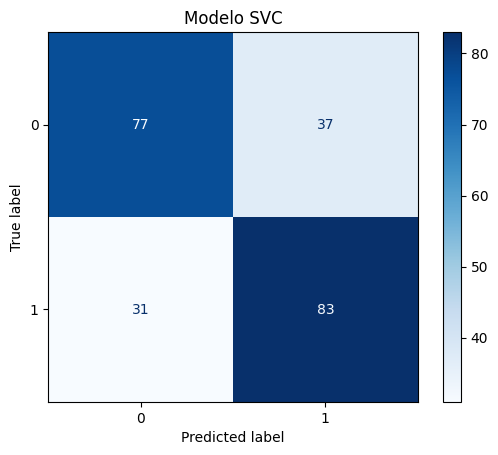

              precision    recall  f1-score   support

           0       0.71      0.68      0.69       114
           1       0.69      0.73      0.71       114

    accuracy                           0.70       228
   macro avg       0.70      0.70      0.70       228
weighted avg       0.70      0.70      0.70       228



In [77]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title('Modelo SVC')

# Mostrar la figura
plt.show()

# Mostrar el informe de clasificación
print(classification_report(y_test, y_pred))

In [78]:
#f1-Score
print("f1-score:",f1_score(y_test, y_pred))

f1-score: 0.7094017094017094


In [79]:
#Crear un dataframe para guardar los resultados
dfResults = pd.DataFrame(columns=['Tipo', 'f1-score'])



dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Lineal y método de retención',
                                      'f1-score': f1_score(y_test, y_pred)}])]
                      , ignore_index=True)

In [80]:
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7094


#### 6.2. Lineal y validación cruzada (*Cross validation*)

##### Creación y entrenamiento del modelo

In [81]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = d.drop(columns ='bad_credit')
y = d['bad_credit']

# la validación cruzada se realiza sobre todo el dataset
X_Completo = X
y_Completo = y

In [82]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numerivas para posteriormente escalarlas
num_vars = numCols

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_Completo[num_vars] = scaler.fit_transform(X_Completo[num_vars])

X_Completo[num_vars].head()

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents
0,0.1176,0.2356,0.6667,0.3333,0.1667,0.3333,0.0000
1,0.1176,0.0619,1.0000,0.6667,0.1296,0.0000,0.0000
2,0.2941,0.1487,1.0000,0.3333,0.1667,0.0000,0.0000
3,0.0735,0.0783,1.0000,0.3333,0.1111,0.0000,0.0000
4,0.3382,0.6167,0.3333,0.3333,0.1296,0.3333,0.0000


In [83]:
# Guardar el scaler

SCALER_FILE_NAME = 'minmaxFull_GermanCredits.pkl'
local_scaler_path = os.path.join(MODELS_SCALER_PATH, SCALER_FILE_NAME)

joblib.dump(scaler,  local_scaler_path)

['modelos/scaler/minmaxFull_GermanCredits.pkl']

In [84]:
CV = 10 #Folks:  Pliegues
scoring = 'f1'


entries = []
accuracies = cross_val_score(modelSVC, X_Completo, y_Completo, cv=CV, scoring=scoring)

for fold_idx, accuracy in enumerate(accuracies):
    entries.append(( fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['fold_idx', 'f1-Score'])

#### Evaluación del modelo

In [85]:
print(cv_df)
print('f1-score:', cv_df['f1-Score'].mean())

   fold_idx  f1-Score
0         0    0.7460
1         1    0.7788
2         2    0.7541
3         3    0.7207
4         4    0.7407
5         5    0.6880
6         6    0.6842
7         7    0.7000
8         8    0.7667
9         9    0.7179
f1-score: 0.7297178541027021


### 7. Afinando el modelo (tuning)

Entre sus parámetros, encontramos:

- C: parámetro de regularización.
- kernel: especifica el tipo de kernel usado por el algoritmo (lineal, polinómico, radial, etc.).
- degree: grado de la función con kernel polinómico.
- gamma: coeficiente del kernel para ‘rbf’, ‘poly’ y ‘sigmoid’.
- probability: indica si se permite la estimación de probabilidades.
- max_iter: límite de iteraciones.
- decision_function_shape: permite establecer el método one-vs-one o one-vs-all.
- random_state: semilla para el generador de número pseudoaleatorios.

El parámetro "C" es el inverso del parámetro λ de regularización por lo cual, si tenemos un valor alto de nuestro parámetro tendremos una mayor varianza y la regularización será menor, mientras que por el contrario, si tenemos un valor bajo, tendremos un mayor efecto de la regularización. Ver: https://dzone.com/articles/support-vector-machines-tutorial

#### 7.1. Lineal e hiperparámetro *C*  (con validación cruzada - *Cross validation*)

##### Identificacion del mejor hiperparametro *C*

In [86]:
#Definicion del modelo
modelsvmL = svm.SVC(kernel='linear', probability = True, random_state = 0)

# Establecemos un grid con los valores de coste que queremos evaluar
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10]}

# definicion de la variable con el número de pliegues
CV = 10

# las metricas sobre las se evaluará el modelo
scoring = 'f1'

# Definimos la busqueda mediante 10-fold CV
grid_svmL = GridSearchCV(estimator = modelsvmL
                             , param_grid = grid_hiperparametros
                             , cv = CV
                             , scoring = scoring
                             , return_train_score = True
                             , verbose=4)



# Aplicamos la busqueda
grid_svmL.fit(X_Completo, y_Completo)

#gridsvmL.cv_results_.keys()

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV 1/10] END ......C=0.001;, score=(train=0.726, test=0.725) total time=   1.0s
[CV 2/10] END ......C=0.001;, score=(train=0.718, test=0.797) total time=   0.6s
[CV 3/10] END ......C=0.001;, score=(train=0.715, test=0.769) total time=   0.5s
[CV 4/10] END ......C=0.001;, score=(train=0.720, test=0.698) total time=   0.6s
[CV 5/10] END ......C=0.001;, score=(train=0.719, test=0.694) total time=   0.5s
[CV 6/10] END ......C=0.001;, score=(train=0.726, test=0.711) total time=   0.5s
[CV 7/10] END ......C=0.001;, score=(train=0.728, test=0.672) total time=   0.5s
[CV 8/10] END ......C=0.001;, score=(train=0.721, test=0.693) total time=   0.4s
[CV 9/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.5s
[CV 10/10] END .....C=0.001;, score=(train=0.667, test=0.663) total time=   0.8s
[CV 1/10] END .......C=0.01;, score=(train=0.711, test=0.744) total time=   0.4s
[CV 2/10] END .......C=0.01;, score=(train=0.7

GridSearchCV(cv=10,
             estimator=SVC(kernel='linear', probability=True, random_state=0),
             param_grid={'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7,
                               10]},
             return_train_score=True, scoring='f1', verbose=4)

In [87]:
# Resultados
resultados = pd.DataFrame(grid_svmL.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_C,mean_test_score,std_test_score,mean_train_score,std_train_score
5,1.0000,0.7297,0.0311,0.7543,0.0039
4,0.5000,0.7291,0.0292,0.7526,0.0033
11,10.0000,0.7275,0.0397,0.7530,0.0073
10,7.0000,0.7275,0.0397,0.7537,0.0072


In [88]:
# Obtener los resultados del grid search
results_grid_svmL = pd.DataFrame(grid_svmL.cv_results_)

# Seleccionar las columnas deseadas
columns_grid_svmL = ['param_C']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_svmL_filtered = results_grid_svmL[columns_grid_svmL]

# Crear la columna scoreWithStd: f1 / std
results_grid_svmL_filtered['scoreWithStd'] = results_grid_svmL_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_svmL_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
print(results_grid_svmL_filtered[['param_C', 'mean_test_score', 'std_test_score', 'scoreWithStd']])

    param_C  mean_test_score  std_test_score  scoreWithStd
0    0.0010           0.6421          0.2176        2.9505
1    0.0100           0.6982          0.0394       17.7109
2    0.1000           0.7214          0.0330       21.8351
3    0.3000           0.7265          0.0328       22.1745
4    0.5000           0.7291          0.0292       24.9446
5    1.0000           0.7297          0.0311       23.4705
6    2.0000           0.7265          0.0400       18.1398
7    3.0000           0.7253          0.0385       18.8586
8    4.0000           0.7260          0.0374       19.4196
9    5.0000           0.7243          0.0403       17.9756
10   7.0000           0.7275          0.0397       18.3205
11  10.0000           0.7275          0.0397       18.3205


In [89]:
# Top 3 de los mejores scores
results_grid_svmL_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_C',  'mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_C,mean_test_score,std_test_score,scoreWithStd
4,0.5000,0.7291,0.0292,24.9446
5,1.0000,0.7297,0.0311,23.4705
3,0.3000,0.7265,0.0328,22.1745


#### Evaluación del modelo

In [90]:
# Seleccionar el registro correspondiente al índice máximo
registro_max_scoreWithStd = results_grid_svmL_filtered.loc[indice_max_scoreWithStd]

registro_max_scoreWithStd.transpose()

,4
param_C,0.5000
mean_test_score,0.7291
std_test_score,0.0292
split0_test_score,0.7559
split1_test_score,0.7636
split2_test_score,0.7377
split3_test_score,0.7273
split4_test_score,0.7339
split5_test_score,0.6935
split6_test_score,0.6842


In [91]:
# Guardar los resultados en el dataframe de resultados

# Guardar los resultados en el dataframe de resultados
dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'lineal e hiperparámetros: C con validación cruzada',
                                      'f1-score': results_grid_svmL_filtered.loc[indice_max_scoreWithStd]['mean_test_score']}])],
                       ignore_index=True)
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7094
1,lineal e hiperparámetros: C con validación cru...,0.7291


#### Creación del modelo final

In [92]:
# Usar los mejores parámetros para crear el modelo
modelsvmL.set_params(kernel='linear'
                     , C = results_grid_svmL_filtered.loc[indice_max_scoreWithStd]['param_C'])

modelsvmL.fit(X_Completo, y_Completo)

SVC(C=np.float64(0.5), kernel='linear', probability=True, random_state=0)

#### 7.2. Polinómico e hiperparámetros: *C* y *degree*  (con validación cruzada  - *Cross validation*)

##### Identificación del mejor hiperparametro *C* y *degree*

In [93]:
#Definición del modelo
modelsvmP = svm.SVC(kernel='poly', probability = True, random_state = 0)

# Establecemos un grid con los valores de coste que queremos evaluar
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10],
                        'degree': [2, 3]}

# definicion de la variable con el número de pliegues
CV = 10

# las metricas sobre las se evaluará el modelo
scoring = 'f1'

# Definimos la busqueda mediante 10-fold CV
grid_svmP = GridSearchCV(estimator = modelsvmP
                             , param_grid = grid_hiperparametros
                             , cv = CV
                             , scoring = scoring
                             , return_train_score = True
                             , verbose=4)


# Aplicamos la busqueda
grid_svmP.fit(X_Completo, y_Completo)

Fitting 10 folds for each of 24 candidates, totalling 240 fits
[CV 1/10] END C=0.001, degree=2;, score=(train=0.730, test=0.720) total time=   0.2s
[CV 2/10] END C=0.001, degree=2;, score=(train=0.720, test=0.770) total time=   0.2s
[CV 3/10] END C=0.001, degree=2;, score=(train=0.722, test=0.752) total time=   0.3s
[CV 4/10] END C=0.001, degree=2;, score=(train=0.727, test=0.700) total time=   0.2s
[CV 5/10] END C=0.001, degree=2;, score=(train=0.735, test=0.677) total time=   0.2s
[CV 6/10] END C=0.001, degree=2;, score=(train=0.734, test=0.713) total time=   0.3s
[CV 7/10] END C=0.001, degree=2;, score=(train=0.723, test=0.706) total time=   0.3s
[CV 8/10] END C=0.001, degree=2;, score=(train=0.727, test=0.725) total time=   0.2s
[CV 9/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 10/10] END C=0.001, degree=2;, score=(train=0.667, test=0.663) total time=   0.2s
[CV 1/10] END C=0.001, degree=3;, score=(train=0.731, test=0.727) total time=   0.2s
[

GridSearchCV(cv=10,
             estimator=SVC(kernel='poly', probability=True, random_state=0),
             param_grid={'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7,
                               10],
                         'degree': [2, 3]},
             return_train_score=True, scoring='f1', verbose=4)

In [94]:
# Resultados
resultados = pd.DataFrame(grid_svmP.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_C,param_degree,mean_test_score,std_test_score,mean_train_score,std_train_score
23,10.0000,3,0.8599,0.0257,0.9948,0.0017
21,7.0000,3,0.8586,0.0264,0.9903,0.0008
19,5.0000,3,0.8574,0.0306,0.9856,0.0020
17,4.0000,3,0.8448,0.0329,0.9813,0.0021


In [95]:
# Obtener los resultados del grid search
results_grid_svmP = pd.DataFrame(grid_svmP.cv_results_)

# Seleccionar las columnas deseadas
columns_grid_svmP = ['param_C']  + \
                    ['param_degree']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_svmP_filtered = results_grid_svmP[columns_grid_svmP]

# Crear la columna scoreWithStd: f1 / std
results_grid_svmP_filtered['scoreWithStd'] = results_grid_svmP_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_svmP_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
print(results_grid_svmP_filtered[['param_C', 'param_degree', 'mean_test_score', 'std_test_score', 'scoreWithStd']])

    param_C  param_degree  mean_test_score  std_test_score  scoreWithStd
0    0.0010             2           0.6425          0.2163        2.9708
1    0.0010             3           0.6464          0.2182        2.9627
2    0.0100             2           0.7191          0.0249       28.8757
3    0.0100             3           0.7241          0.0331       21.8787
4    0.1000             2           0.7277          0.0280       25.9840
5    0.1000             3           0.7642          0.0156       48.8740
6    0.3000             2           0.7563          0.0164       46.1666
7    0.3000             3           0.7936          0.0197       40.3309
8    0.5000             2           0.7719          0.0167       46.3010
9    0.5000             3           0.7978          0.0287       27.7623
10   1.0000             2           0.7791          0.0258       30.1940
11   1.0000             3           0.8032          0.0275       29.2294
12   2.0000             2           0.7913         

In [96]:
# Top 3 de los mejores scores
results_grid_svmP_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_C', 'param_degree', 'mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_C,param_degree,mean_test_score,std_test_score,scoreWithStd
5,0.1000,3,0.7642,0.0156,48.8740
8,0.5000,2,0.7719,0.0167,46.3010
6,0.3000,2,0.7563,0.0164,46.1666


#### Evaluación del modelo

In [97]:
# Seleccionar el registro correspondiente al índice máximo
registro_max_scoreWithStd = results_grid_svmP_filtered.loc[indice_max_scoreWithStd]

registro_max_scoreWithStd.transpose()

,5
param_C,0.1000
param_degree,3.0000
mean_test_score,0.7642
std_test_score,0.0156
split0_test_score,0.7820
split1_test_score,0.7966
split2_test_score,0.7603
split3_test_score,0.7458
split4_test_score,0.7500
split5_test_score,0.7692


In [98]:

dfResults = pd.concat([dfResults,
                       pd.DataFrame({'Tipo': ['Polinómico e hiperparámetros: C y degree con validación cruzada'],
                                     'f1-score': [results_grid_svmP_filtered.loc[indice_max_scoreWithStd]['mean_test_score']]} )],
                       ignore_index=True)

#### Creación del modelo final

In [99]:
# Usar los mejores parámetros para crear el modelo
modelsvmP.set_params(kernel='poly'
                     , C = results_grid_svmP_filtered.loc[indice_max_scoreWithStd]['param_C']
                     , degree = int(results_grid_svmP_filtered.loc[indice_max_scoreWithStd]['param_degree'])
                    )

modelsvmP.fit(X_Completo, y_Completo)

SVC(C=np.float64(0.1), kernel='poly', probability=True, random_state=0)

#### 7.3. Radial e hiperparámetros: *C* y *gamma*  (con validación cruzada  - *Cross validation*)

##### Identificación del mejor hiperparametro *C* y *gamma*

In [100]:
#Definición del modelo
modelsvmR = svm.SVC(kernel='rbf', probability = True, random_state = 0)



# Establecemos un grid con los valores de coste que queremos evaluar
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10],
                        'gamma': ['scale', 'auto']}

# definicion de la variable con el número de pliegues
CV = 10

# Definimos las metricas sobre las que queremos evaluar
scoring = 'f1'

# Definimos la busqueda mediante 10-fold CV
grid_svmR = GridSearchCV(estimator = modelsvmR
                             , param_grid = grid_hiperparametros
                             , cv = CV
                             , scoring = scoring
                             , return_train_score = True
                             , verbose=4)


# Aplicamos la busqueda
grid_svmR.fit(X_Completo, y_Completo)

Fitting 10 folds for each of 24 candidates, totalling 240 fits
[CV 1/10] END C=0.001, gamma=scale;, score=(train=0.727, test=0.737) total time=   0.4s
[CV 2/10] END C=0.001, gamma=scale;, score=(train=0.726, test=0.783) total time=   0.3s
[CV 3/10] END C=0.001, gamma=scale;, score=(train=0.726, test=0.758) total time=   0.3s
[CV 4/10] END C=0.001, gamma=scale;, score=(train=0.730, test=0.683) total time=   0.3s
[CV 5/10] END C=0.001, gamma=scale;, score=(train=0.719, test=0.705) total time=   0.3s
[CV 6/10] END C=0.001, gamma=scale;, score=(train=0.730, test=0.688) total time=   0.3s
[CV 7/10] END C=0.001, gamma=scale;, score=(train=0.733, test=0.672) total time=   0.3s
[CV 8/10] END C=0.001, gamma=scale;, score=(train=0.722, test=0.688) total time=   0.5s
[CV 9/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.5s
[CV 10/10] END C=0.001, gamma=scale;, score=(train=0.667, test=0.663) total time=   0.5s
[CV 1/10] END C=0.001, gamma=auto;, score=(train=0.725, 

GridSearchCV(cv=10, estimator=SVC(probability=True, random_state=0),
             param_grid={'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7,
                               10],
                         'gamma': ['scale', 'auto']},
             return_train_score=True, scoring='f1', verbose=4)

In [101]:
# Resultados
resultados = pd.DataFrame(grid_svmR.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_C,param_gamma,mean_test_score,std_test_score,mean_train_score,std_train_score
22,10.0000,scale,0.8657,0.0269,0.9885,0.0022
20,7.0000,scale,0.8510,0.0326,0.9805,0.0016
18,5.0000,scale,0.8411,0.0356,0.9700,0.0023
16,4.0000,scale,0.8353,0.0372,0.9603,0.0028


In [102]:
# Obtener los resultados del grid search
results_grid_svmR = pd.DataFrame(grid_svmR.cv_results_)

# Seleccionar las columnas deseadas
columns_grid_svmR = ['param_C']  + \
                    ['param_gamma']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_svmR_filtered = results_grid_svmR[columns_grid_svmR]

# Crear la columna scoreWithStd: f1 / std
results_grid_svmR_filtered['scoreWithStd'] = results_grid_svmR_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_svmR_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
print(results_grid_svmR_filtered[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'scoreWithStd']])

    param_C param_gamma  mean_test_score  std_test_score  scoreWithStd
0    0.0010       scale           0.6376          0.2157        2.9556
1    0.0010        auto           0.6433          0.2183        2.9467
2    0.0100       scale           0.6376          0.2157        2.9556
3    0.0100        auto           0.6433          0.2183        2.9467
4    0.1000       scale           0.7216          0.0251       28.7651
5    0.1000        auto           0.6935          0.0323       21.4750
6    0.3000       scale           0.7348          0.0241       30.4554
7    0.3000        auto           0.7006          0.0373       18.7669
8    0.5000       scale           0.7672          0.0222       34.5803
9    0.5000        auto           0.6983          0.0320       21.7995
10   1.0000       scale           0.7980          0.0192       41.6536
11   1.0000        auto           0.7104          0.0353       20.1250
12   2.0000       scale           0.8136          0.0280       29.0600
13   2

In [103]:
# Top 3 de los mejores scores
results_grid_svmR_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_C,param_gamma,mean_test_score,std_test_score,scoreWithStd
10,1.0000,scale,0.7980,0.0192,41.6536
23,10.0000,auto,0.7723,0.0193,39.9991
8,0.5000,scale,0.7672,0.0222,34.5803


#### Evaluación del modelo

In [104]:
# Seleccionar el registro correspondiente al índice máximo
registro_max_scoreWithStd = results_grid_svmR_filtered.loc[indice_max_scoreWithStd]

registro_max_scoreWithStd.transpose()

,10
param_C,1.0000
param_gamma,scale
mean_test_score,0.7980
std_test_score,0.0192
split0_test_score,0.7907
split1_test_score,0.8070
split2_test_score,0.7833
split3_test_score,0.7895
split4_test_score,0.7869
split5_test_score,0.7937


In [105]:
dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Radial e hiperparámetros: C y gamma con validación cruzada',
                                      'f1-score': results_grid_svmR_filtered.loc[indice_max_scoreWithStd]['mean_test_score']}])],
                      ignore_index=True)



#dfResults = dfResults.append(pd.DataFrame(
#                {'Tipo': ['Radial e hiperparámetros: C y gamma con validación cruzada'],
#                 'f1-score':results_grid_svmR_filtered.loc[indice_max_scoreWithStd]['mean_test_score']}))
#dfResults

#### Creación del modelo final

In [106]:
# Usar los mejores parámetros para crear el modelo
modelsvmR.set_params(kernel='rbf'
                     , C = results_grid_svmR_filtered.loc[indice_max_scoreWithStd]['param_C']
                     , gamma = results_grid_svmR_filtered.loc[indice_max_scoreWithStd]['param_gamma']
                    )

modelsvmR.fit(X_Completo, y_Completo)

SVC(C=np.float64(1.0), probability=True, random_state=0)

### 8. Eligiendo el modelo

In [107]:
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7094
1,lineal e hiperparámetros: C con validación cru...,0.7291
2,Polinómico e hiperparámetros: C y degree con v...,0.7642
3,Radial e hiperparámetros: C y gamma con valida...,0.7980


### Guardar modelo

In [108]:
#Se guardan los modelos de SVC

model_files = {
    modelsvmL: 'SVC_CV_lineal.pkl',
    modelsvmP: 'SVC_CV_poly.pkl',
    modelsvmR: 'SVC_CV_rbf.pkl'
}

for model, file_name in model_files.items():
    local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, file_name)
    joblib.dump(model, local_model_path)
    print(f"Modelo '{file_name}' guardado exitosamente en: {local_model_path}")

Modelo 'SVC_CV_lineal.pkl' guardado exitosamente en: modelos/clasificacion/SVC_CV_lineal.pkl
Modelo 'SVC_CV_poly.pkl' guardado exitosamente en: modelos/clasificacion/SVC_CV_poly.pkl
Modelo 'SVC_CV_rbf.pkl' guardado exitosamente en: modelos/clasificacion/SVC_CV_rbf.pkl


#### Referencias


- Maquinas de vectores de soporte

    - https://www.datacamp.com/community/tutorials/svm-classification-scikit-learn-python
    
    
- Tuning parametros SVM
    - https://github.com/CristinaGil/Ciencia-de-Datos-Python/blob/master/maquinas_vector_soporte.ipynb
    

- Hiperparametros y Kernels

    - https://ichi.pro/es/hiperparametros-de-svm-explicados-con-visualizaciones-22257741819931

    - https://jakevdp.github.io/PythonDataScienceHandbook/05.07-support-vector-machines.html


- *scikit-learn:*   
    - https://scikit-learn.org/stable/modules/svm.html



- *Gráficas con  seaborn:*
    - https://ichi.pro/es/como-utilizar-python-seaborn-para-analisis-de-datos-exploratorios-28897898172180


- *Multicolinealidad:*
    - https://www.analyticslane.com/2020/04/22/solucionar-la-multicolinealidad-con-vif/


- *Analítica de grandes datos:*
    - https://jdvelasq.github.io/courses/analitica-de-grandes-datos/index.html